# Previsão de Preços de Casas — Ames Housing

Este notebook replica e expande o projeto de previsão de preços de casas de Ammar Alyousfi (Kaggle), usando o dataset Ames Housing. Em vez de seguir a metodologia do autor de forma linear, o objetivo aqui é comparar diretamente as decisões metodológicas dele com uma abordagem alternativa, para entender empiricamente o impacto real de cada escolha — em vez de assumir que a abordagem de um notebook de referência é necessariamente a ideal.

Ao longo do notebook, são mantidos dois datasets em paralelo: um seguindo minha própria abordagem, e outro reproduzindo as escolhas específicas do autor (marcado com sufixo `_a`), permitindo comparar os resultados finais lado a lado.

In [100]:
#importando as bibliotecas

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

## Entendendo o dataset

Antes de qualquer tratamento, vale entender a estrutura geral do dataset: quantas variáveis são numéricas vs. categóricas, e qual a distribuição básica de cada uma. Isso orienta as decisões de tratamento de dados faltantes e de codificação que vêm a seguir.

In [101]:
df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [102]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [103]:
df.describe(include=["object"]).transpose().drop("count", axis=1)#entendendo os dados de strings

C:\Users\eopal\AppData\Local\Temp\ipykernel_37688\4061971944.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"]).transpose().drop("count", axis=1)#entendendo os dados de strings


,unique,top,freq
MS Zoning,7,RL,2273
Street,2,Pave,2918
Alley,2,Grvl,120
Lot Shape,4,Reg,1859
Land Contour,4,Lvl,2633
Utilities,3,AllPub,2927
Lot Config,5,Inside,2140
Land Slope,3,Gtl,2789
Neighborhood,28,NAmes,443
Condition 1,9,Norm,2522


## Tratamento de Dados Faltantes

O tratamento de valores ausentes segue a documentação oficial do dataset: em várias colunas, um valor nulo não significa "dado desconhecido", mas sim "a casa não possui esse elemento" (garagem, porão, alpendre, etc.). Por isso, o preenchimento é feito de forma diferenciada — variáveis categóricas relacionadas a elementos ausentes recebem um rótulo próprio (`"NT"`), e variáveis numéricas relacionadas recebem `0`.

No entanto, esse preenchimento genérico não é aplicado cegamente: antes de aplicá-lo, investigo casos onde outras colunas da mesma linha contradizem a hipótese de "elemento ausente" — esses casos são tratados individualmente, como detalhado abaixo.

In [104]:
valores_faltantes = df.isna().sum()
valores_faltantes = valores_faltantes[valores_faltantes > 0]

porcentagem_faltante = valores_faltantes * 100 / df.shape[0]
tipos_dados = df[valores_faltantes.index].dtypes
tabela_faltantes = (
    pd.concat(
        [valores_faltantes, porcentagem_faltante, tipos_dados],
        axis=1,
        keys=["valores_faltantes", "porcentagem_faltante", "tipo"],
    )
    .sort_values(by="valores_faltantes", ascending=False)
)

tabela_faltantes

,valores_faltantes,porcentagem_faltante,tipo
Pool QC,2917,99.556314,str
Misc Feature,2824,96.382253,str
Alley,2732,93.242321,str
Fence,2358,80.477816,str
Mas Vnr Type,1775,60.580205,str
Fireplace Qu,1422,48.532423,str
Lot Frontage,490,16.723549,float64
Garage Qual,159,5.426621,str
Garage Cond,159,5.426621,str
Garage Yr Blt,159,5.426621,float64


### Nota metodológica: exceções no tratamento do porão

O preenchimento genérico de dados faltantes do porão (`colunas_s` → `"NT"`) assume que todo valor nulo significa "a casa não tem porão". Investigando caso a caso, encontrei 3 exceções a essa regra:

- **Linhas 66 e 2779**: `Bsmt Qual = "Gd"` e `Bsmt Cond = "TA"` confirmam que a casa **tem** porão, mas `Bsmt Exposure` estava nulo. Preenchi com `"No"` (sem exposição), que é um valor válido da escala da variável — diferente de "sem porão".
- **Linha 444**: `BsmtFin SF 2 = 479.0` (área acabada registrada) confirma um porão com segunda área finalizada, mas `BsmtFin Type 2` estava nulo. Preenchi com `"Unf"` (unfinished), seguindo a mesma lógica.

Sem essa checagem, essas 3 linhas teriam recebido `"NT"` incorretamente, criando uma contradição dentro da própria linha (features dizendo "tem porão" e "não tem porão" ao mesmo tempo).

In [105]:
df.loc[[66, 2779], 'Bsmt Exposure'] = 'No'
df.loc[444, 'BsmtFin Type 2'] = 'Unf'

colunas_s = [
    "Alley",
    "Misc Feature",
    "Pool QC",
    "Fence",
    'Bsmt Qual',
    "Bsmt Cond",
    "Mas Vnr Type",
    "Fireplace Qu",
    "Garage Qual",
    "Garage Cond",
    "Garage Finish",
    "Garage Type",
    "BsmtFin Type 1",
]  

colunas_n = [
    "Mas Vnr Area",
    "Lot Frontage",
    "Garage Yr Blt",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Total Bsmt SF",
    "Bsmt Unf SF",
]


df[colunas_n] = df[colunas_n].fillna(0.0)
df[colunas_s] = df[colunas_s].fillna("NT")

In [106]:
df.loc[[66, 2779], 'Bsmt Exposure'] = 'No'
df.loc[444, 'BsmtFin Type 2'] = 'Unf'

In [107]:
df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna('NT')
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].fillna('NT')

In [108]:
df.tail()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0,7937,Pave,NT,IR1,Lvl,...,0,NT,GdPrv,NT,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,0.0,8885,Pave,NT,IR1,Low,...,0,NT,MnPrv,NT,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NT,Reg,Lvl,...,0,NT,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NT,Reg,Lvl,...,0,NT,NT,NT,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,NT,Reg,Lvl,...,0,NT,NT,NT,0,11,2006,WD,Normal,188000


In [109]:
# Analise de variaveis com valores faltantes e tipo
valores_faltantes = df.isna().sum()
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Porcentagem de valores faltantes
porcentagem_faltante = valores_faltantes * 100 / df.shape[0]

# Tipo de dado das colunas com nulos
tipos_dados = df[valores_faltantes.index].dtypes

# Concatenação e ordenação do DataFrame final
tabela_faltantes = (
    pd.concat(
        [valores_faltantes, porcentagem_faltante, tipos_dados],
        axis=1,
        keys=["valores_faltantes", "porcentagem_faltante", "tipo"],
    )
    .sort_values(by="valores_faltantes", ascending=False)
)

tabela_faltantes

,valores_faltantes,porcentagem_faltante,tipo
Electrical,1,0.03413,str
Garage Cars,1,0.03413,float64
Garage Area,1,0.03413,float64


Na analise dos dados faltantes, Já podemos presumir que uma casa que está sendo vendida, dificilmente não tera energia, então, possivelmente trata-se de um dado faltante

In [110]:
df['Electrical'].value_counts()

Electrical
SBrkr    2682
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [111]:
moda_electrical = df["Electrical"].mode()[0]
df["Electrical"] = df["Electrical"].fillna(moda_electrical)

Fazendo a moda, o valor que sera colocado sera o "SBrkr" que é disparado o mais usado pelas casas a venda

Partindo para a garagem temos uma diferença no tratamento dos dados. a casa pode ser sim sem garagem mas vamos analisar todas as colunas referentes a garagem para podermos fazer uma analise completa

In [112]:
colunas_garagem = ["Garage Type", "Garage Yr Blt", "Garage Finish", "Garage Cars", "Garage Area", "Garage Qual", "Garage Cond"]
df.loc[2236, colunas_garagem]

Garage Type      Detchd
Garage Yr Blt       0.0
Garage Finish        NT
Garage Cars         NaN
Garage Area         NaN
Garage Qual          NT
Garage Cond          NT
Name: 2236, dtype: object

### Nota metodológica: dados faltantes na garagem

Ao investigar a linha 2236, identifiquei uma inconsistência que uma abordagem de preenchimento genérico não capturaria: `Garage Type = "Detchd"` (ou seja, a casa **tem** garagem), mas as demais colunas de garagem estavam nulas ou zeradas. Isso não é ausência de garagem — é dado faltante de verdade.

Em vez de rotular essa linha como "sem garagem" (que distorceria a informação), calculei a mediana (para colunas numéricas) e a moda (para colunas categóricas) **apenas entre as casas com `Garage Type = "Detchd"`**, e usei esses valores para preencher a linha 2236. Isso preserva a integridade da informação: a casa continua sendo registrada como tendo garagem, com valores plausíveis para as demais características.

In [113]:
# Pegando apenas garagens do tipo Detchd para calcular valores típicos
detchd = df[df["Garage Type"] == "Detchd"]

mediana_cars = detchd["Garage Cars"].median()
mediana_area = detchd["Garage Area"].median()
moda_qual = detchd["Garage Qual"].mode()[0]
moda_cond = detchd["Garage Cond"].mode()[0]
moda_finish = detchd["Garage Finish"].mode()[0]

# Aplicando só na linha 2236
df.loc[2236, "Garage Cars"] = mediana_cars
df.loc[2236, "Garage Area"] = mediana_area
df.loc[2236, "Garage Qual"] = moda_qual
df.loc[2236, "Garage Cond"] = moda_cond
df.loc[2236, "Garage Finish"] = moda_finish

In [114]:
colunas_garagem = ["Garage Type", "Garage Yr Blt", "Garage Finish", "Garage Cars", "Garage Area", "Garage Qual", "Garage Cond"]
df.loc[2236, colunas_garagem]

Garage Type      Detchd
Garage Yr Blt       0.0
Garage Finish       Unf
Garage Cars         2.0
Garage Area       400.0
Garage Qual          TA
Garage Cond          TA
Name: 2236, dtype: object

As variaveis numericas, foram usados a mediana porque ela é a que melhor pode colocar valores corretos da casa nesse caso especifico.

Nas de object, foi usado a moda, para identificar um padrão na classe Detchd

A Coluna Garage Yr Blt não tem como ser feita uma predição já que o ano em que foi construida não tem como ser estimada

In [115]:
df['Electrical'].value_counts()

Electrical
SBrkr    2683
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [116]:
# Analise de variaveis com valores faltantes e tipo
valores_faltantes = df.isna().sum()
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Porcentagem de valores faltantes
porcentagem_faltante = valores_faltantes * 100 / df.shape[0]

# Tipo de dado das colunas com nulos
tipos_dados = df[valores_faltantes.index].dtypes

# Concatenação e ordenação do DataFrame final
tabela_faltantes = (
    pd.concat(
        [valores_faltantes, porcentagem_faltante, tipos_dados],
        axis=1,
        keys=["valores_faltantes", "porcentagem_faltante", "tipo"],
    )
    .sort_values(by="valores_faltantes", ascending=False)
)

tabela_faltantes

,valores_faltantes,porcentagem_faltante,tipo


### Nota metodológica: exceções no tratamento do porão

O preenchimento genérico de dados faltantes do porão (`colunas_s` → `"NT"`) assume que todo valor nulo significa "a casa não tem porão". Investigando caso a caso, encontrei 3 exceções a essa regra:

- **Linhas 66 e 2779**: `Bsmt Qual = "Gd"` e `Bsmt Cond = "TA"` confirmam que a casa **tem** porão, mas `Bsmt Exposure` estava nulo. Preenchi com `"No"` (sem exposição), que é um valor válido da escala da variável — diferente de "sem porão".
- **Linha 444**: `BsmtFin SF 2 = 479.0` (área acabada registrada) confirma um porão com segunda área finalizada, mas `BsmtFin Type 2` estava nulo. Preenchi com `"Unf"` (unfinished), seguindo a mesma lógica.

Sem essa checagem, essas 3 linhas teriam recebido `"NT"` incorretamente, criando uma contradição dentro da própria linha (features dizendo "tem porão" e "não tem porão" ao mesmo tempo).

In [117]:
df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna('NT')
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].fillna('NT')

In [118]:
# Analise de variaveis com valores faltantes e tipo
valores_faltantes = df.isna().sum()
valores_faltantes = valores_faltantes[valores_faltantes > 0]

# Porcentagem de valores faltantes
porcentagem_faltante = valores_faltantes * 100 / df.shape[0]

# Tipo de dado das colunas com nulos
tipos_dados = df[valores_faltantes.index].dtypes

# Concatenação e ordenação do DataFrame final
tabela_faltantes = (
    pd.concat(
        [valores_faltantes, porcentagem_faltante, tipos_dados],
        axis=1,
        keys=["valores_faltantes", "porcentagem_faltante", "tipo"],
    )
    .sort_values(by="valores_faltantes", ascending=False)
)

tabela_faltantes

,valores_faltantes,porcentagem_faltante,tipo


## Remoção de Outliers

Seguindo a recomendação do próprio criador do dataset (De Cock, 2011), removo as 5 observações com `Gr Liv Area` acima de 4.000 pés quadrados. Essas casas se destacam visivelmente do restante da distribuição no gráfico de dispersão `SalePrice` vs. `Gr Liv Area`, e sua remoção é uma prática amplamente adotada por quem trabalha com este dataset.

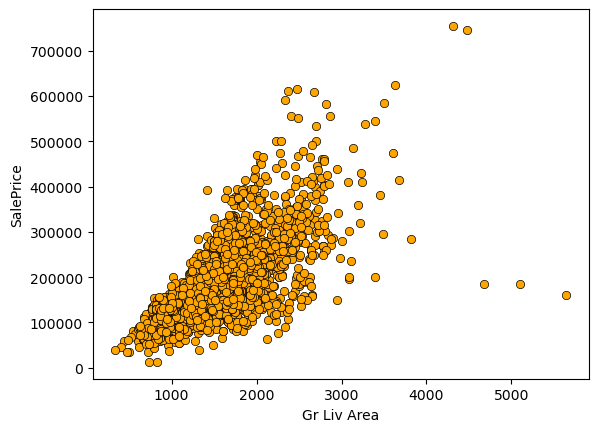

In [119]:
plt.scatter(x=df['Gr Liv Area'], y=df['SalePrice'], 
            color="orange", edgecolors="#000000", linewidths=0.5);
plt.xlabel("Gr Liv Area"); plt.ylabel("SalePrice");

como podemos ver, os valorres com mais de 4 mil, desgarram da maioria dos valores de venda.

In [120]:
valores_acima = df[df['Gr Liv Area']>4000]

In [121]:
df = df.drop(valores_acima.index)
df = df.reset_index(drop=True)

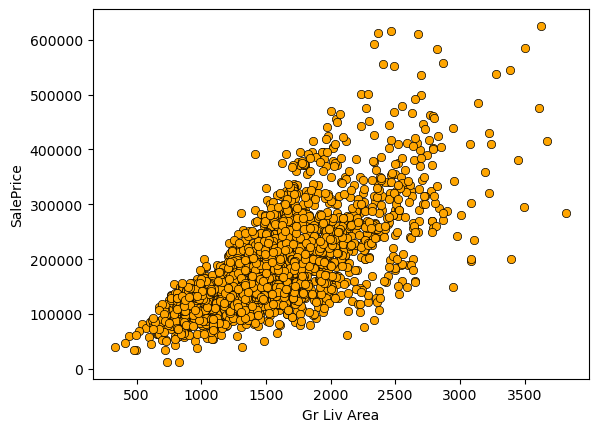

In [122]:
plt.scatter(x=df['Gr Liv Area'], y=df['SalePrice'], 
            color="orange", edgecolors="#000000", linewidths=0.5);
plt.xlabel("Gr Liv Area"); plt.ylabel("SalePrice");

In [123]:
df.drop(columns=['Order', 'PID'], inplace=True)

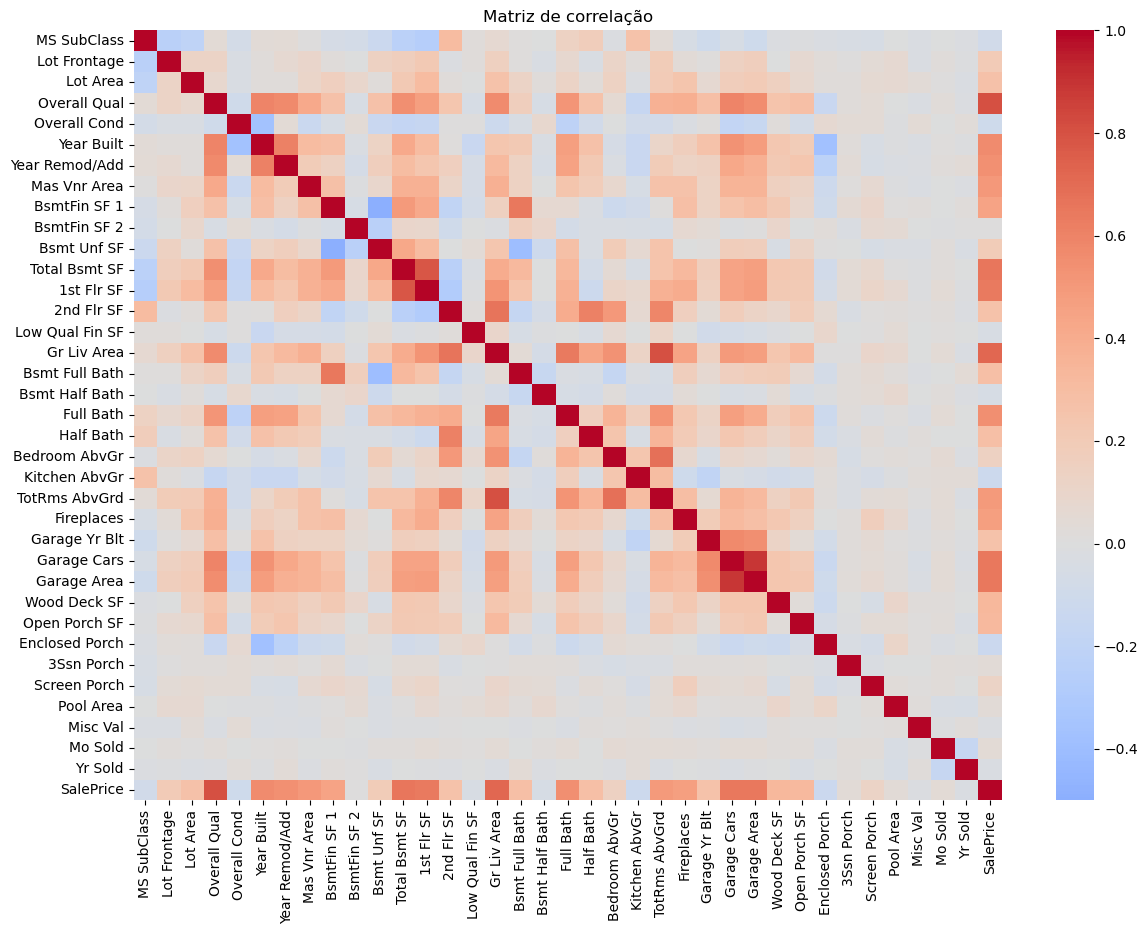

In [124]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlação")
plt.show()

Gráficos de matriz de correlação são recorrentes em problemas de predição de valores, e por isso trago essa visualização aqui: o heatmap mostra, pelo tom de vermelho, o quanto cada feature está positivamente correlacionada com o preço do imóvel — quanto mais intenso o vermelho na linha/coluna `SalePrice`, mais forte a relação. Um exemplo claro é `Garage Area`: quanto maior a área da garagem, maior tende a ser o preço de venda. Outras variáveis como `Year Built` e a área do porão (`Total Bsmt SF`) também apresentam relação positiva direta com o preço.

Vale destacar que correlação não implica causalidade: essas variáveis estão associadas ao preço, mas isso não significa necessariamente que aumentá-las, isoladamente, causaria um aumento no valor do imóvel.

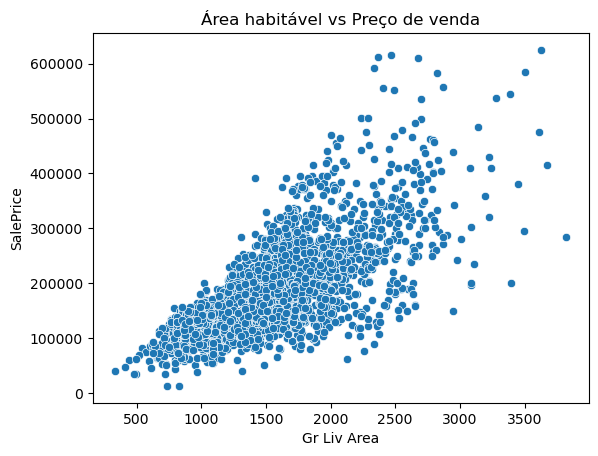

In [125]:
sns.scatterplot(data=df, x="Gr Liv Area", y="SalePrice")
plt.title("Área habitável vs Preço de venda")
plt.show()

Este gráfico de dispersão relaciona a área habitável acima do solo (`Gr Liv Area`) com o preço de venda da casa. É possível notar uma tendência clara: à medida que a área habitável aumenta, o preço de venda também tende a subir — o que é esperado, já que essa métrica engloba ambientes como quartos, cozinha e banheiros, refletindo diretamente o tamanho útil do imóvel.

Vale reforçar, no entanto, que essa relação não é determinística: existem casas com áreas semelhantes vendidas por valores bem diferentes (visível na dispersão vertical dos pontos em cada faixa de área), o que indica que `Gr Liv Area` é um fator relevante, mas não o único — nem necessariamente causal — na formação do preço final.

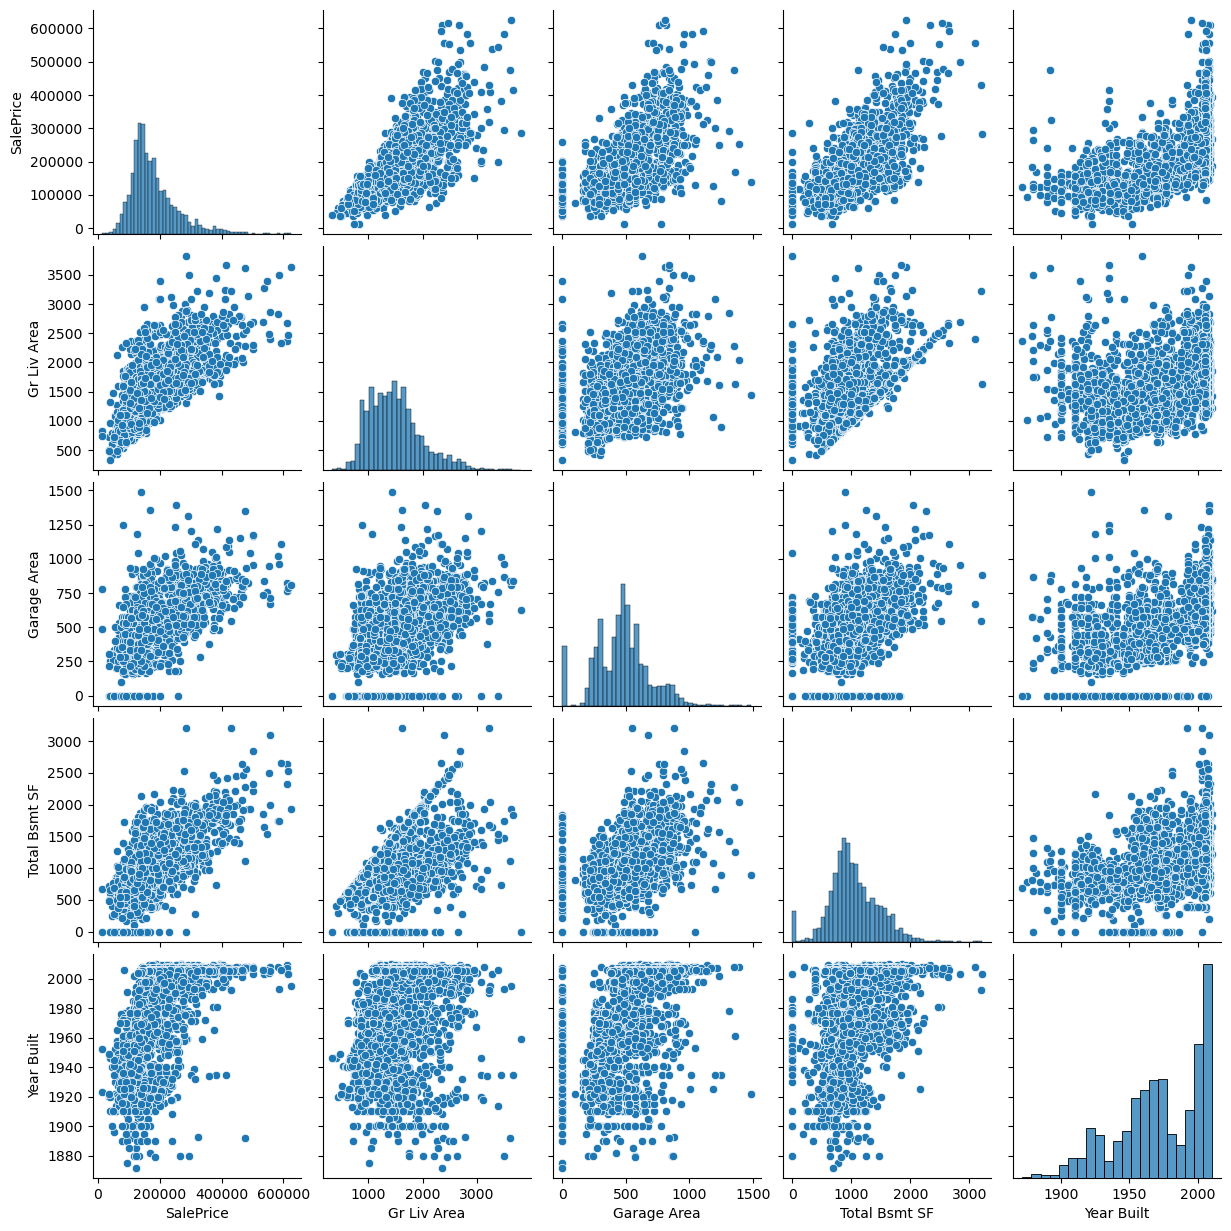

In [126]:
colunas_interesse = ["SalePrice", "Gr Liv Area", "Garage Area", "Total Bsmt SF", "Year Built"]
sns.pairplot(df[colunas_interesse])
plt.show()

Este pairplot relaciona simultaneamente cinco variáveis: `SalePrice`, `Gr Liv Area`, `Garage Area`, `Total Bsmt SF` e `Year Built`. Na diagonal, temos a distribuição individual de cada variável; fora da diagonal, a dispersão entre cada par.

O padrão mais evidente é que `Gr Liv Area` e `Total Bsmt SF` apresentam uma relação bastante linear e positiva com `SalePrice`, reforçando o que já havíamos visto isoladamente. `Garage Area` também mostra uma tendência positiva, porém com uma dispersão maior — inclusive um grupo de casas sem garagem (`Garage Area = 0`) espalhado por praticamente toda a faixa de preços, o que indica que a ausência de garagem, sozinha, não define um preço baixo.

`Year Built` se comporta de forma diferente das demais: a relação com `SalePrice` é mais dispersa e menos linear, mas ainda é possível notar uma leve tendência de casas mais recentes concentrarem os preços mais altos, enquanto casas mais antigas aparecem em praticamente toda a faixa de preço, sugerindo que o ano de construção sozinho tem menor poder explicativo do que as variáveis de área.

Assim como nos gráficos anteriores, essas relações indicam associação, não causalidade — cada variável é um fator que pode contribuir para o preço final, mas não determina isoladamente o valor de venda.

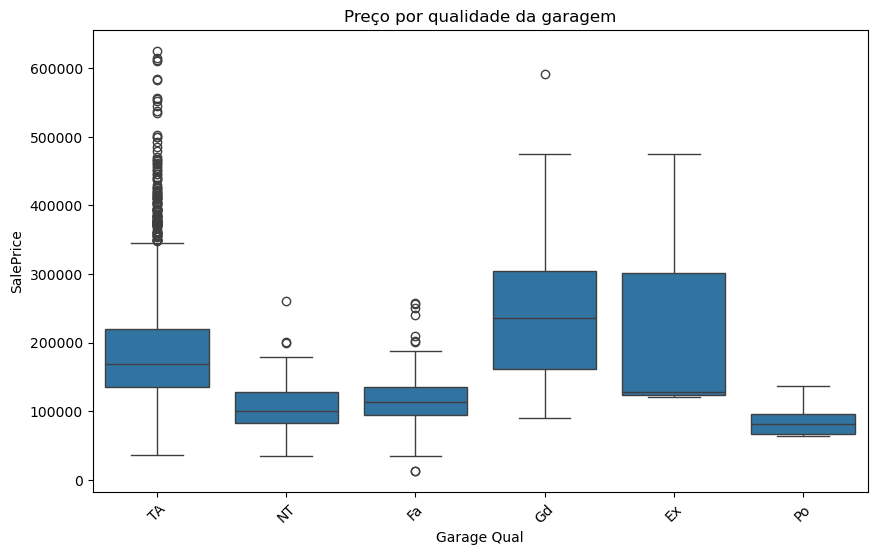

In [127]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Garage Qual", y="SalePrice")
plt.xticks(rotation=45)
plt.title("Preço por qualidade da garagem")
plt.show()

Este boxplot mostra a relação entre o preço de venda (`SalePrice`) e a qualidade da garagem (`Garage Qual`), uma variável categórica ordinal. Cada caixa representa a distribuição de preços dentro de uma categoria: a linha central é a mediana, os limites da caixa marcam o primeiro e o terceiro quartil (ou seja, onde ficam os 50% centrais dos dados), e os "bigodes" se estendem até o restante da distribuição considerada normal. Os pontos isolados fora dos bigodes são outliers — casas com preço muito acima ou abaixo do range típico daquela categoria.

Um padrão interessante aparece aqui: as categorias `Gd` (boa) e `Ex` (excelente) têm as medianas de preço mais altas, como esperado. Porém, a categoria `TA` (típica) concentra o maior número de outliers para cima — o que faz sentido, já que é também a categoria com mais casas no dataset, aumentando a chance de valores extremos aparecerem. Já a categoria `NT` (sem garagem) tem preços relativamente próximos aos de `Fa` (garagem de qualidade regular), o que sugere que a ausência de garagem por si só não é o fator mais determinante no preço — outras características da casa parecem pesar mais.

In [128]:
df[["Garage Cars", "Garage Area"]].corr()

,Garage Cars,Garage Area
Garage Cars,1.000000,0.891996
Garage Area,0.891996,1.000000


In [129]:
df[["Gr Liv Area", "TotRms AbvGrd"]].corr()

,Gr Liv Area,TotRms AbvGrd
Gr Liv Area,1.000000,0.809118
TotRms AbvGrd,0.809118,1.000000


## Feature Engineering: Multicolinearidade e Features Polinomiais

O notebook de referência do Kaggle toma duas decisões nesta etapa: remover `Garage Cars` e `TotRms AbvGrd` por colinearidade com `Garage Area` e `Gr Liv Area`, respectivamente; e criar features polinomiais (quadrado e cubo) e uma feature de interação para `Overall Qual` e `Gr Liv Area`, as duas variáveis mais correlacionadas com o alvo.

Em vez de aplicar essas transformações diretamente, mantenho dois datasets em paralelo — um sem essas transformações (abordagem própria) e outro reproduzindo as decisões do autor (`_a`) — para comparar o efeito real dessas escolhas nos resultados finais de cada algoritmo, na seção de resultados.

In [130]:
df_a = df.copy()
for f in ["Overall Qual", "Gr Liv Area"]:
    df_a[f + "_p2"] = df[f] ** 2
    df_a[f + "_p3"] = df[f] ** 3

df_a["OverallQual_GrLivArea"] = df_a["Overall Qual"] * df_a["Gr Liv Area"]
df_a.drop(["Garage Cars", "TotRms AbvGrd"],axis=1, inplace=True)

agora podemos seguir com o notebook, proximo passo está em analisar as variaveis categoricas

In [131]:
mp = {'Ex':4,'Gd':3,'TA':2,'Fa':1,'Po':0}
df['Exter Qual'] = df['Exter Qual'].map(mp)
df['Exter Cond'] = df['Exter Cond'].map(mp)
df['Heating QC'] = df['Heating QC'].map(mp)
df['Kitchen Qual'] = df['Kitchen Qual'].map(mp)

mp = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0}
df['Bsmt Qual'] = df['Bsmt Qual'].map(mp)
df['Bsmt Cond'] = df['Bsmt Cond'].map(mp)
df['Bsmt Exposure'] = df['Bsmt Exposure'].map(
    {'Gd':4,'Av':3,'Mn':2,'No':1,'NT':0})

mp = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NT':0}
df['BsmtFin Type 1'] = df['BsmtFin Type 1'].map(mp)
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].map(mp)

df['Central Air'] = df['Central Air'].map({'Y':1,'N':0})
df['Functional'] = df['Functional'].map(
    {'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,
    'Maj2':2,'Sev':1,'Sal':0})
df['Fireplace Qu'] = df['Fireplace Qu'].map(
    {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0})
df['Garage Finish'] = df['Garage Finish'].map(
    {'Fin':3,'RFn':2,'Unf':1,'NT':0})
df['Garage Qual'] = df['Garage Qual'].map(
    {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0})
df['Garage Cond'] = df['Garage Cond'].map(
    {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0})
df['Pool QC'] = df['Pool QC'].map(
    {'Ex':4,'Gd':3,'TA':2,'Fa':1,'NT':0})
df['Land Slope'] = df['Land Slope'].map(
    {'Sev': 2, 'Mod': 1, 'Gtl': 0})
df['Fence'] = df['Fence'].map(
    {'GdPrv':4,'MnPrv':3,'GdWo':2,'MnWw':1,'NT':0})

In [132]:
mp = {'Ex':4,'Gd':3,'TA':2,'Fa':1,'Po':0}
df_a['Exter Qual'] = df_a['Exter Qual'].map(mp)
df_a['Exter Cond'] = df_a['Exter Cond'].map(mp)
df_a['Heating QC'] = df_a['Heating QC'].map(mp)
df_a['Kitchen Qual'] = df_a['Kitchen Qual'].map(mp)

mp = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0}
df_a['Bsmt Qual'] = df_a['Bsmt Qual'].map(mp)
df_a['Bsmt Cond'] = df_a['Bsmt Cond'].map(mp)
df_a['Bsmt Exposure'] = df_a['Bsmt Exposure'].map(
    {'Gd':4,'Av':3,'Mn':2,'No':1,'NT':0})

mp = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NT':0}
df_a['BsmtFin Type 1'] = df_a['BsmtFin Type 1'].map(mp)
df_a['BsmtFin Type 2'] = df_a['BsmtFin Type 2'].map(mp)

df_a['Central Air'] = df_a['Central Air'].map({'Y':1,'N':0})
df_a['Functional'] = df_a['Functional'].map(
    {'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,
    'Maj2':2,'Sev':1,'Sal':0})
df_a['Fireplace Qu'] = df_a['Fireplace Qu'].map(
    {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0})
df_a['Garage Finish'] = df_a['Garage Finish'].map(
    {'Fin':3,'RFn':2,'Unf':1,'NT':0})
df_a['Garage Qual'] = df_a['Garage Qual'].map(
    {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0})
df_a['Garage Cond'] = df_a['Garage Cond'].map(
    {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NT':0})
df_a['Pool QC'] = df_a['Pool QC'].map(
    {'Ex':4,'Gd':3,'TA':2,'Fa':1,'NT':0})
df_a['Land Slope'] = df_a['Land Slope'].map(
    {'Sev': 2, 'Mod': 1, 'Gtl': 0})
df_a['Fence'] = df_a['Fence'].map(
    {'GdPrv':4,'MnPrv':3,'GdWo':2,'MnWw':1,'NT':0})

Nessa parte demos um valor categorico as features, as outras que sobraram, não são classificações, apenas descrições do imovel.
Agora para as outras variaveis, aplicaremos o one hot encoding

In [133]:
df = pd.get_dummies(df)
df_a = pd.get_dummies(df_a)
df = df.astype({col: 'int64' for col in df.select_dtypes(include=['bool']).columns})
df_a = df_a.astype({col: 'int64' for col in df_a.select_dtypes(include=['bool']).columns})
df

,MS SubClass,Lot Frontage,Lot Area,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,20,141.0,31770,0,6,5,1960,1960,112.0,2,...,0,0,0,1,0,0,0,0,1,0
1,20,80.0,11622,0,5,6,1961,1961,0.0,2,...,0,0,0,1,0,0,0,0,1,0
2,20,81.0,14267,0,6,6,1958,1958,108.0,2,...,0,0,0,1,0,0,0,0,1,0
3,20,93.0,11160,0,7,5,1968,1968,0.0,3,...,0,0,0,1,0,0,0,0,1,0
4,60,74.0,13830,0,5,5,1997,1998,0.0,2,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,80,37.0,7937,0,6,6,1984,1984,0.0,2,...,0,0,0,1,0,0,0,0,1,0
2921,20,0.0,8885,1,5,5,1983,1983,0.0,2,...,0,0,0,1,0,0,0,0,1,0
2922,85,62.0,10441,0,5,5,1992,1992,0.0,2,...,0,0,0,1,0,0,0,0,1,0
2923,20,77.0,10010,1,5,5,1974,1975,0.0,2,...,0,0,0,1,0,0,0,0,1,0


In [134]:
X = df.drop(columns='SalePrice')
y = df['SalePrice']

X_a = df_a.drop(columns='SalePrice')
y_a = df_a['SalePrice']

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    random_state=3)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a,
                                                    y_a,
                                                    test_size=0.25,
                                                    random_state=3)  

## Divisão Treino/Teste e Escalonamento

Um ponto de atenção nesta etapa: o escalonamento (`StandardScaler`) deve ser ajustado apenas com os dados de treino, e aplicado (sem novo ajuste) aos dados de teste. Ajustar o scaler no dataset inteiro antes da divisão — como ocorre no notebook de referência original — causa vazamento de dado (data leakage): a média e o desvio-padrão usados para padronizar as features passam a incorporar informação do conjunto de teste, o que infla artificialmente a performance do modelo nessa avaliação.

Por isso, a divisão treino/teste é feita antes do escalonamento, e o scaler é ajustado exclusivamente com `X_train`. (Diferente da abordagem do autor)

In [136]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [137]:
X_train

array([[-0.16536148,  0.07780844,  0.11858728, ..., -0.11974379,
         0.45270858, -0.2972162 ],
       [ 0.0685229 ,  0.85970513,  0.5721176 , ..., -0.11974379,
         0.45270858, -0.2972162 ],
       [-0.86701463, -1.72656852,  0.78511624, ..., -0.11974379,
         0.45270858, -0.2972162 ],
       ...,
       [-0.86701463,  0.37853794, -0.23143921, ..., -0.11974379,
         0.45270858, -0.2972162 ],
       [-0.86701463,  1.58145591,  0.53833864, ..., -0.11974379,
        -2.20892656,  3.36455416],
       [-0.86701463, -0.22292105, -0.65131804, ..., -0.11974379,
         0.45270858, -0.2972162 ]], shape=(2193, 239))

In [138]:
scaler = StandardScaler()
X_train_a = scaler.fit_transform(X_train_a)
X_test_a = scaler.transform(X_test_a)

In [139]:
X_train_a

array([[-0.16536148,  0.07780844,  0.11858728, ..., -0.11974379,
         0.45270858, -0.2972162 ],
       [ 0.0685229 ,  0.85970513,  0.5721176 , ..., -0.11974379,
         0.45270858, -0.2972162 ],
       [-0.86701463, -1.72656852,  0.78511624, ..., -0.11974379,
         0.45270858, -0.2972162 ],
       ...,
       [-0.86701463,  0.37853794, -0.23143921, ..., -0.11974379,
         0.45270858, -0.2972162 ],
       [-0.86701463,  1.58145591,  0.53833864, ..., -0.11974379,
        -2.20892656,  3.36455416],
       [-0.86701463, -0.22292105, -0.65131804, ..., -0.11974379,
         0.45270858, -0.2972162 ]], shape=(2193, 242))

## Modelagem e Busca de Hiperparâmetros

Para cada algoritmo, o mesmo espaço de busca de hiperparâmetros é aplicado às duas versões do dataset (própria e a do autor), usando `GridSearchCV`/`RandomizedSearchCV` com a métrica de erro absoluto médio (MAE) como critério de seleção. Manter o mesmo espaço de busca entre as duas versões garante que a comparação final isole o efeito da engenharia de features, e não de uma busca de hiperparâmetros diferente entre elas.

In [140]:
parametro_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    "fit_intercept": [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
}

parametro_elastic_net = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [2000]
}

parametro_Ne = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],      
    'weights': ['uniform', 'distance'],       
    'metric': ['euclidean', 'manhattan']                              
}

parametro_svr = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'gamma': ['scale', 'auto']
}


parametro_dt = {
        'criterion': ['squared_error', 'absolute_error', 'poisson'],
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
}


parametro_nn = {
        "hidden_layer_sizes": [(7,)*3, (19,), (100,), (154,)],
        "activation": ["identity", "logistic", "tanh", "relu"],
        "solver": ["lbfgs"],
        "alpha": [1, 10, 100],
}

parametro_rf = {
        "n_estimators": [10, 100, 300, 600],
        "criterion": ['squared_error', 'absolute_error'],
        "max_depth": [7, 50, 254],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 5],
        "max_features": [19, 100, X_train.shape[1]],
        "bootstrap": [True, False],
    }

parametro_gb = {
        "max_depth": [4, 5, 6],
        "learning_rate": [0.005, 0.009, 0.01],
        "n_estimators": [700, 1000, 2500],
        "booster": ["gbtree",],
        "gamma": [7, 25, 100],
        "subsample": [0.3, 0.6],
        "colsample_bytree": [0.5, 0.7],
        "colsample_bylevel": [0.5, 0.7,],
        "reg_alpha": [1, 10, 33],
        "reg_lambda": [1, 3, 10],
    }

In [141]:
grid_ridge = GridSearchCV(
    estimator=Ridge(random_state=3),
    param_grid=parametro_ridge,
    cv=4,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [142]:
# 3. Executa a busca (use os dados padronizados se já tiver aplicado o StandardScaler)
grid_ridge.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Ridge:", grid_ridge.best_params_)
print("Melhor MAE na Validação Cruzada:", -grid_ridge.best_score_)
melhores_parametros_rg = grid_ridge.best_params_

Melhores parâmetros para o Ridge: {'alpha': 100.0, 'fit_intercept': True, 'solver': 'lsqr'}
Melhor MAE na Validação Cruzada: 16317.436880220845


In [143]:
# 3. Executa a busca (use os dados padronizados se já tiver aplicado o StandardScaler)
grid_ridge.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Ridge:", grid_ridge.best_params_)
print("Melhor MAE na Validação Cruzada:", -grid_ridge.best_score_)
melhores_parametros_rg_a = grid_ridge.best_params_

Melhores parâmetros para o Ridge: {'alpha': 0.01, 'fit_intercept': True, 'solver': 'svd'}
Melhor MAE na Validação Cruzada: 15059.102969297903


In [144]:
rg_model = Ridge(random_state=3, **melhores_parametros_rg)

rg_model.fit(X_train, y_train)
y_pred_rg = rg_model.predict(X_test)
rg_mae = mean_absolute_error(y_test,y_pred_rg)
print("Ridge MAE=",rg_mae)

Ridge MAE= 16604.527016604326


In [145]:
rg_model_a = Ridge(random_state=3, **melhores_parametros_rg_a)

rg_model_a.fit(X_train_a, y_train_a)
y_pred_a_rg = rg_model_a.predict(X_test_a)
rg_mae_a = mean_absolute_error(y_test_a,y_pred_a_rg)
print("Ridge MAE=",rg_mae_a)

Ridge MAE= 14847.025127313242


In [146]:
#Elastic Net

In [147]:
grid_Elastic_Net = GridSearchCV(
    estimator=ElasticNet(random_state=42),
    param_grid=parametro_elastic_net,
    cv=4,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [148]:
grid_Elastic_Net.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Elastic Net:", grid_Elastic_Net.best_params_)
print("Melhor MAE na Validação Cruzada:", -grid_Elastic_Net.best_score_)
melhores_parametros_en = grid_Elastic_Net.best_params_

Melhores parâmetros para o Elastic Net: {'alpha': 1.0, 'l1_ratio': 0.9, 'max_iter': 2000}
Melhor MAE na Validação Cruzada: 16220.726957341883


In [149]:
grid_Elastic_Net.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Elastic Net:", grid_Elastic_Net.best_params_)
print("Melhor MAE na Validação Cruzada:", -grid_Elastic_Net.best_score_)
melhores_parametros_en = grid_Elastic_Net.best_params_

Melhores parâmetros para o Elastic Net: {'alpha': 1.0, 'l1_ratio': 0.7, 'max_iter': 2000}
Melhor MAE na Validação Cruzada: 15144.755598739417


In [150]:
en_model = ElasticNet(random_state=3, **melhores_parametros_en)

en_model.fit(X_train, y_train)
y_pred_en = en_model.predict(X_test)
en_mae = mean_absolute_error(y_test,y_pred_en)
print("Elastic MAE=",en_mae)

Elastic MAE= 16329.918430889504


In [151]:
en_model.fit(X_train_a, y_train_a)
y_pred_en_a = en_model.predict(X_test_a)
en_mae_a = mean_absolute_error(y_test_a,y_pred_en_a)
print("Elastic MAE=",en_mae_a)

Elastic MAE= 15199.94260305399


In [152]:
#Neighbors


In [153]:
grid_Nearest_Neighbors = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=parametro_Ne,
    cv=4,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)



In [154]:
grid_Nearest_Neighbors.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Nearest_Neighbors:", grid_Nearest_Neighbors.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Nearest_Neighbors.best_score_)
melhores_parametros_nn = grid_Nearest_Neighbors.best_params_

Melhores parâmetros para o Nearest_Neighbors: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Melhor MAE na Validação Cruzada: -20729.556476809223


In [155]:
grid_Nearest_Neighbors.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Nearest_Neighbors:", grid_Nearest_Neighbors.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Nearest_Neighbors.best_score_)
melhores_parametros_nn_a = grid_Nearest_Neighbors.best_params_

Melhores parâmetros para o Nearest_Neighbors: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Melhor MAE na Validação Cruzada: -19403.482876094855


In [156]:
nn_model = KNeighborsRegressor(**melhores_parametros_nn)

nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
nn_mae = mean_absolute_error(y_test,y_pred_nn)
print("KNeighborsRegressor MAE=",nn_mae)

KNeighborsRegressor MAE= 21079.365814301425


In [157]:
nn_model = KNeighborsRegressor(**melhores_parametros_nn_a)

nn_model.fit(X_train_a, y_train_a)
y_pred_nn_a = nn_model.predict(X_test_a)
nn_mae_a = mean_absolute_error(y_test_a,y_pred_nn_a)
print("KNeighborsRegressor MAE=",nn_mae_a)

KNeighborsRegressor MAE= 19679.37747003931


In [158]:
#Suporte Vector Regressor

In [159]:
grid_Support_Vector_Regression = GridSearchCV(
    estimator=SVR(),
    param_grid=parametro_svr,
    cv=4,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

In [160]:
grid_Support_Vector_Regression.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Nearest_Neighbors:", grid_Support_Vector_Regression.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Support_Vector_Regression.best_score_)
melhores_parametros_Svr = grid_Support_Vector_Regression.best_params_

Melhores parâmetros para o Nearest_Neighbors: {'C': 100, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
Melhor MAE na Validação Cruzada: -16034.530968563751


In [161]:
grid_Support_Vector_Regression.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Svr:", grid_Support_Vector_Regression.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Support_Vector_Regression.best_score_)
melhores_parametros_Svr_a = grid_Support_Vector_Regression.best_params_

Melhores parâmetros para o Svr: {'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Melhor MAE na Validação Cruzada: -14980.713490455882


In [162]:
SVR_model = SVR(**melhores_parametros_Svr)

SVR_model.fit(X_train, y_train)
y_pred_svr = SVR_model.predict(X_test)
svr_mae = mean_absolute_error(y_test,y_pred_svr)
print("SVR MAE=",svr_mae)

SVR MAE= 15925.641091259586


In [163]:
SVR_model_a = SVR(**melhores_parametros_Svr_a)

SVR_model_a.fit(X_train_a, y_train_a)
y_pred_svr_a = SVR_model_a.predict(X_test_a)
svr_mae_a = mean_absolute_error(y_test_a,y_pred_svr_a)
print("SVR MAE=",svr_mae_a)

SVR MAE= 14813.168648456052


In [164]:
#Arvore de decisão

In [165]:
grid_Decision_tree = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=3),
    param_grid=parametro_dt,
    cv=4,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [166]:
grid_Decision_tree.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a arvore de decisão:", grid_Decision_tree.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Decision_tree.best_score_)
melhores_parametros_dt = grid_Decision_tree.best_params_

Melhores parâmetros para a arvore de decisão: {'criterion': 'absolute_error', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Melhor MAE na Validação Cruzada: -22058.69699719464


In [167]:
grid_Decision_tree.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a arvore de decisão:", grid_Decision_tree.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Decision_tree.best_score_)
melhores_parametros_dt_a = grid_Decision_tree.best_params_

Melhores parâmetros para a arvore de decisão: {'criterion': 'absolute_error', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
Melhor MAE na Validação Cruzada: -21385.108378870675


In [168]:
DecisionTreeRegressor_model = DecisionTreeRegressor(**melhores_parametros_dt)

DecisionTreeRegressor_model.fit(X_train, y_train)
y_pred_dt = DecisionTreeRegressor_model.predict(X_test)
dt_mae = mean_absolute_error(y_test,y_pred_dt)
print("Arvore de decisão MAE=",dt_mae)

Arvore de decisão MAE= 24026.849043715847


In [169]:
DecisionTreeRegressor_model_a = DecisionTreeRegressor(**melhores_parametros_dt_a)

DecisionTreeRegressor_model_a.fit(X_train_a, y_train_a)
y_pred_dt_a = DecisionTreeRegressor_model_a.predict(X_test_a)
dt_mae_a = mean_absolute_error(y_test_a,y_pred_dt_a)
print("Arvore de decisão MAE=",dt_mae_a)

Arvore de decisão MAE= 22390.909836065573


In [170]:
#Neural Network

In [171]:
grid_Neural_Network = GridSearchCV(
    estimator=MLPRegressor(random_state=3),
    param_grid=parametro_nn,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=4
)

In [172]:
grid_Neural_Network.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a Neural Network:", grid_Neural_Network.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Neural_Network.best_score_)
melhores_parametros_nnn = grid_Neural_Network.best_params_

Melhores parâmetros para a Neural Network: {'activation': 'identity', 'alpha': 10, 'hidden_layer_sizes': (7, 7, 7), 'solver': 'lbfgs'}
Melhor MAE na Validação Cruzada: -17375.712573405628


c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [173]:
grid_Neural_Network.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a Neural Network:", grid_Neural_Network.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Neural_Network.best_score_)
melhores_parametros_nnn_a = grid_Neural_Network.best_params_

Melhores parâmetros para a Neural Network: {'activation': 'identity', 'alpha': 10, 'hidden_layer_sizes': (154,), 'solver': 'lbfgs'}
Melhor MAE na Validação Cruzada: -17018.355693518854


c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [174]:
Neural_Network_model = MLPRegressor(**melhores_parametros_nnn)

Neural_Network_model.fit(X_train, y_train)
y_pred_nnn = Neural_Network_model.predict(X_test)
nnn_mae = mean_absolute_error(y_test,y_pred_nnn)
print("Neural Network MAE=",nnn_mae)

Neural Network MAE= 16927.943878121485


c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [175]:
Neural_Network_model_a = MLPRegressor(**melhores_parametros_nnn_a)

Neural_Network_model_a.fit(X_train_a, y_train_a)
y_pred_nnn_a = Neural_Network_model_a.predict(X_test_a)
nnn_mae_a = mean_absolute_error(y_test_a,y_pred_nnn_a)
print("Neural Network MAE=",nnn_mae_a)

Neural Network MAE= 14827.059232866957


c:\Users\eopal\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [176]:
#random forest

In [177]:
grid_Random_Forest = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=3),
    param_distributions=parametro_rf,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=4,
    n_iter=10,
    random_state=3
)

In [178]:
grid_Random_Forest.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a Random Forest:", grid_Random_Forest.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Random_Forest.best_score_)
melhores_parametros_rf = grid_Random_Forest.best_params_

Melhores parâmetros para a Random Forest: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 19, 'max_depth': 254, 'criterion': 'squared_error', 'bootstrap': False}
Melhor MAE na Validação Cruzada: -15208.95842757258


In [179]:
grid_Random_Forest.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para o Random Forest:", grid_Random_Forest.best_params_)
print("Melhor MAE na Validação Cruzada:", grid_Random_Forest.best_score_)
melhores_parametros_rf_a = grid_Random_Forest.best_params_

Melhores parâmetros para o Random Forest: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 19, 'max_depth': 254, 'criterion': 'squared_error', 'bootstrap': False}
Melhor MAE na Validação Cruzada: -14956.924572883416


In [180]:
model_Random_Forest = RandomForestRegressor(**melhores_parametros_rf)

model_Random_Forest.fit(X_train, y_train)
y_pred_rf = model_Random_Forest.predict(X_test)
rf_mae = mean_absolute_error(y_test,y_pred_rf)
print("Random Forest MAE=",rf_mae)

Random Forest MAE= 14447.441643897997


In [181]:
model_Random_Forest = RandomForestRegressor(**melhores_parametros_rf_a)

model_Random_Forest.fit(X_train_a, y_train_a)
y_pred_rf_a = model_Random_Forest.predict(X_test_a)
rf_mae_a = mean_absolute_error(y_test_a,y_pred_rf_a)
print("Random Forest MAE=",rf_mae_a)

Random Forest MAE= 14387.398861566484


In [182]:
#Gradiente Boosting

In [183]:
grid_Gradiente_Boosting = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=3),
    param_distributions=parametro_gb,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=4,
    n_iter=10,
    random_state=3
)

In [184]:
grid_Gradiente_Boosting.fit(X_train, y_train)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a Gradiente Boosting", grid_Gradiente_Boosting.best_params_)
print("Melhor MAE na Validação Cruzada", grid_Gradiente_Boosting.best_score_)
melhores_parametros_gb = grid_Gradiente_Boosting.best_params_

Melhores parâmetros para a Gradiente Boosting {'subsample': 0.3, 'reg_lambda': 3, 'reg_alpha': 33, 'n_estimators': 2500, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 25, 'colsample_bytree': 0.5, 'colsample_bylevel': 0.5, 'booster': 'gbtree'}
Melhor MAE na Validação Cruzada -13050.474283854166


In [185]:
grid_Gradiente_Boosting.fit(X_train_a, y_train_a)

# 4. Exibe os melhores resultados
print("Melhores parâmetros para a Gradiente Boosting", grid_Gradiente_Boosting.best_params_)
print("Melhor MAE na Validação Cruzada", grid_Gradiente_Boosting.best_score_)
melhores_parametros_gb_a = grid_Gradiente_Boosting.best_params_

Melhores parâmetros para a Gradiente Boosting {'subsample': 0.3, 'reg_lambda': 3, 'reg_alpha': 33, 'n_estimators': 2500, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 25, 'colsample_bytree': 0.5, 'colsample_bylevel': 0.5, 'booster': 'gbtree'}
Melhor MAE na Validação Cruzada -13072.791015625


In [186]:
model_Gradiente_Boosting = XGBRegressor(**melhores_parametros_gb)

model_Gradiente_Boosting.fit(X_train, y_train)
y_pred_gb = model_Gradiente_Boosting.predict(X_test)
gb_mae = mean_absolute_error(y_test,y_pred_gb)
print("Gradiente Boosting MAE=",gb_mae)

Gradiente Boosting MAE= 12432.0830078125


In [187]:
model_Gradiente_Boosting_a = XGBRegressor(**melhores_parametros_gb_a)

model_Gradiente_Boosting_a.fit(X_train_a, y_train_a)
y_pred_gb_a = model_Gradiente_Boosting_a.predict(X_test_a)
gb_mae_a = mean_absolute_error(y_test_a,y_pred_gb_a)
print("Gradiente Boosting MAE=",gb_mae_a)

Gradiente Boosting MAE= 12654.1884765625


## Resultados Finais

A tabela abaixo compara o MAE de cada algoritmo nas duas abordagens (própria vs. autor), no conjunto de teste. Os resultados mostram um padrão interessante: para os modelos de ensemble baseados em árvore (Random Forest, Gradient Boosting), a engenharia de features do autor tem efeito neutro ou levemente negativo. Já para os demais modelos (lineares regularizados, SVR, KNN, árvore única, rede neural), a abordagem do autor traz uma melhora consistente — provavelmente porque esses algoritmos são mais sensíveis a colinearidade e a relações não-lineares que os termos polinomiais ajudam a capturar diretamente.

In [188]:
import pandas as pd

# Dicionário: nome do modelo -> (MAE meu, MAE do autor)
resultados = {
    "Ridge":              (rg_mae,  rg_mae_a),
    "Elastic Net":        (en_mae,  en_mae_a),
    "KNN":                (nn_mae,  nn_mae_a),
    "SVR":                (svr_mae, svr_mae_a),
    "Árvore de Decisão":  (dt_mae,  dt_mae_a),
    "Neural Network":     (nnn_mae, nnn_mae_a),
    "Random Forest":      (rf_mae,  rf_mae_a),
    "Gradient Boosting":  (gb_mae,  gb_mae_a),
}

tabela_resultados = pd.DataFrame(
    [(modelo, meu, autor) for modelo, (meu, autor) in resultados.items()],
    columns=["Modelo", "MAE (Meu)", "MAE (Autor)"]
).sort_values(by="MAE (Meu)").reset_index(drop=True)

tabela_resultados

,Modelo,MAE (Meu),MAE (Autor)
0,Gradient Boosting,12432.083008,12654.188477
1,Random Forest,14447.441644,14387.398862
2,SVR,15925.641091,14813.168648
3,Elastic Net,16329.918431,15199.942603
4,Ridge,16604.527017,14847.025127
5,Neural Network,16927.943878,14827.059233
6,KNN,21079.365814,19679.377470
7,Árvore de Decisão,24026.849044,22390.909836


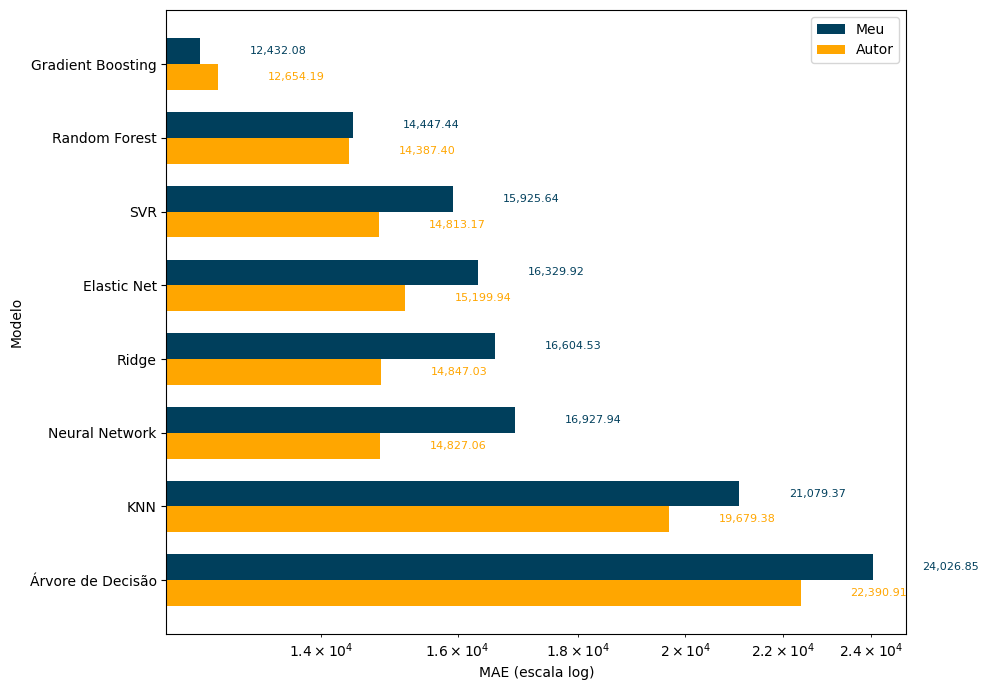

In [189]:
from matplotlib import pyplot as plt
import numpy as np

# Ordena por MAE (Meu), do menor para o maior
tabela_ordenada = tabela_resultados.sort_values(by="MAE (Meu)").reset_index(drop=True)

x = tabela_ordenada["Modelo"].tolist()
meu = tabela_ordenada["MAE (Meu)"].tolist()
autor = tabela_ordenada["MAE (Autor)"].tolist()

ind = np.arange(len(x))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.barh(ind - height/2, meu, height, color="#003f5c", label="Meu")
bars2 = ax.barh(ind + height/2, autor, height, color="#ffa600", label="Autor")

ax.set_xscale("log")
ax.set_yticks(ind)
ax.set_yticklabels(x)
ax.invert_yaxis()  # menor MAE no topo
ax.set_xlabel("MAE (escala log)")
ax.set_ylabel("Modelo")
ax.legend()

# Rótulos com o valor exato ao final de cada barra
for bar, valor in zip(bars1, meu):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f"{valor:,.2f}", va="center", fontsize=8, color="#003f5c")

for bar, valor in zip(bars2, autor):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f"{valor:,.2f}", va="center", fontsize=8, color="#ffa600")

plt.tight_layout()
plt.show()

In [190]:
import pandas as pd

# MAE original do autor no Kaggle (CDL - com data leakage no scaling, publicado no notebook)
mae_autor_cdl = {
    "XGBoost / Gradient Boosting":  12556.68,
    "SVR":                          12874.93,
    "Random Forest":                14506.46,
    "Elastic Net":                  14767.91,
    "Ridge":                        15270.46,
    "Neural Network":               15656.38,
    "Decision Tree / Árvore de Decisão": 20873.95,
    "KNN":                          22780.14,
}

# Minha abordagem (SDL - sem data leakage, sem multicolinearidade removida, sem polinômio)
mae_meu_sdl = {
    "XGBoost / Gradient Boosting":        12432.083008,
    "SVR":                                15925.641091,
    "Random Forest":                      14482.313531,
    "Elastic Net":                        16329.918431,
    "Ridge":                              16604.527017,
    "Neural Network":                     16978.666223,
    "Decision Tree / Árvore de Decisão":  23973.920082,
    "KNN":                                21079.365814,
}

# Abordagem do autor reproduzida (SDL - mesma engenharia de features dele, mas com scaling corrigido)
mae_autor_sdl = {
    "XGBoost / Gradient Boosting":        12654.188477,
    "SVR":                                14813.168648,
    "Random Forest":                      14480.970551,
    "Elastic Net":                        15199.942603,
    "Ridge":                              14847.025127,
    "Neural Network":                     14779.263499,
    "Decision Tree / Árvore de Decisão":  22274.939891,
    "KNN":                                19679.377470,
}

modelos = list(mae_autor_cdl.keys())

tabela_comparativa = pd.DataFrame({
    "Modelo": modelos,
    "MAE Autor Kaggle (CDL)": [mae_autor_cdl[m] for m in modelos],
    "MAE Meu (SDL)": [mae_meu_sdl[m] for m in modelos],
    "MAE Autor Reproduzido (SDL)": [mae_autor_sdl[m] for m in modelos],
})

tabela_comparativa = tabela_comparativa.sort_values(by="MAE Meu (SDL)").reset_index(drop=True)
tabela_comparativa

,Modelo,MAE Autor Kaggle (CDL),MAE Meu (SDL),MAE Autor Reproduzido (SDL)
0,XGBoost / Gradient Boosting,12556.68,12432.083008,12654.188477
1,Random Forest,14506.46,14482.313531,14480.970551
2,SVR,12874.93,15925.641091,14813.168648
3,Elastic Net,14767.91,16329.918431,15199.942603
4,Ridge,15270.46,16604.527017,14847.025127
5,Neural Network,15656.38,16978.666223,14779.263499
6,KNN,22780.14,21079.365814,19679.377470
7,Decision Tree / Árvore de Decisão,20873.95,23973.920082,22274.939891


CDL = Com Data Lakage
SDL = Sem Data Lagage

## Análise Comparativa: Autor Kaggle (CDL) vs. Minha Abordagem (SDL) vs. Autor Reproduzido (SDL)

A tabela acima reúne três cenários para os mesmos 8 algoritmos de regressão:

- **MAE Autor Kaggle (CDL)**: resultado publicado no notebook original de referência, obtido com vazamento de dado no escalonamento (o `StandardScaler` era ajustado no dataset inteiro antes da divisão treino/teste).
- **MAE Meu (SDL)**: minha abordagem (sem remoção de multicolinearidade, sem features polinomiais), sem nenhum vazamento de dado.
- **MAE Autor Reproduzido (SDL)**: a mesma engenharia de features do autor (remoção de multicolinearidade + termos polinomiais), reproduzida no meu notebook, também sem vazamento de dado.

### Leitura dos resultados

**Comparação controlada (Meu vs. Autor Reproduzido, ambas colunas SDL):** essa é a comparação mais confiável, já que as duas usam o mesmo protocolo (sem vazamento, mesmo espaço de busca de hiperparâmetros), diferindo apenas na engenharia de features. Ela mostra um padrão claro: para os modelos de ensemble baseados em árvore (Gradient Boosting, Random Forest), a engenharia de features do autor tem efeito neutro ou levemente negativo. Para os demais modelos (SVR, Elastic Net, Ridge, Neural Network, KNN, Árvore de Decisão), a abordagem do autor melhora o resultado de forma consistente — provavelmente porque esses algoritmos são mais sensíveis a colinearidade e a relações não-lineares que os termos polinomiais ajudam a capturar diretamente, enquanto ensembles de árvore já lidam bem com esses dois problemas por conta própria.

**Comparação com o notebook publicado (Autor Kaggle CDL vs. Autor Reproduzido SDL):** aqui o movimento não é uniforme — SVR e Árvore de Decisão pioram sem o vazamento, enquanto Ridge, Neural Network e KNN melhoram. Isso indica que essa comparação específica não isola de forma limpa o efeito do vazamento de escalonamento: ela também carrega diferenças no espaço de busca de hiperparâmetros entre a reprodução e o notebook original publicado. Por isso, essa coluna deve ser lida como contexto histórico (o que foi publicado originalmente), não como uma medição controlada do impacto exato do vazamento — essa medição controlada é a comparação entre as duas colunas SDL, descrita acima.

### Conclusão desta seção

Buscando uma similaridade entre os três cenários, um padrão se repete: o Gradient Boosting/XGBoost aparece com o menor MAE nas três colunas, independentemente de haver vazamento ou de qual engenharia de features foi aplicada. Isso sugere que a robustez desse tipo de modelo (ensemble de árvores com boosting) se mantém relativamente estável diante dessas variações metodológicas, reforçando que a escolha do algoritmo tem peso considerável no resultado final, complementar às camadas de tratamento de dado e engenharia de features discutidas anteriormente.

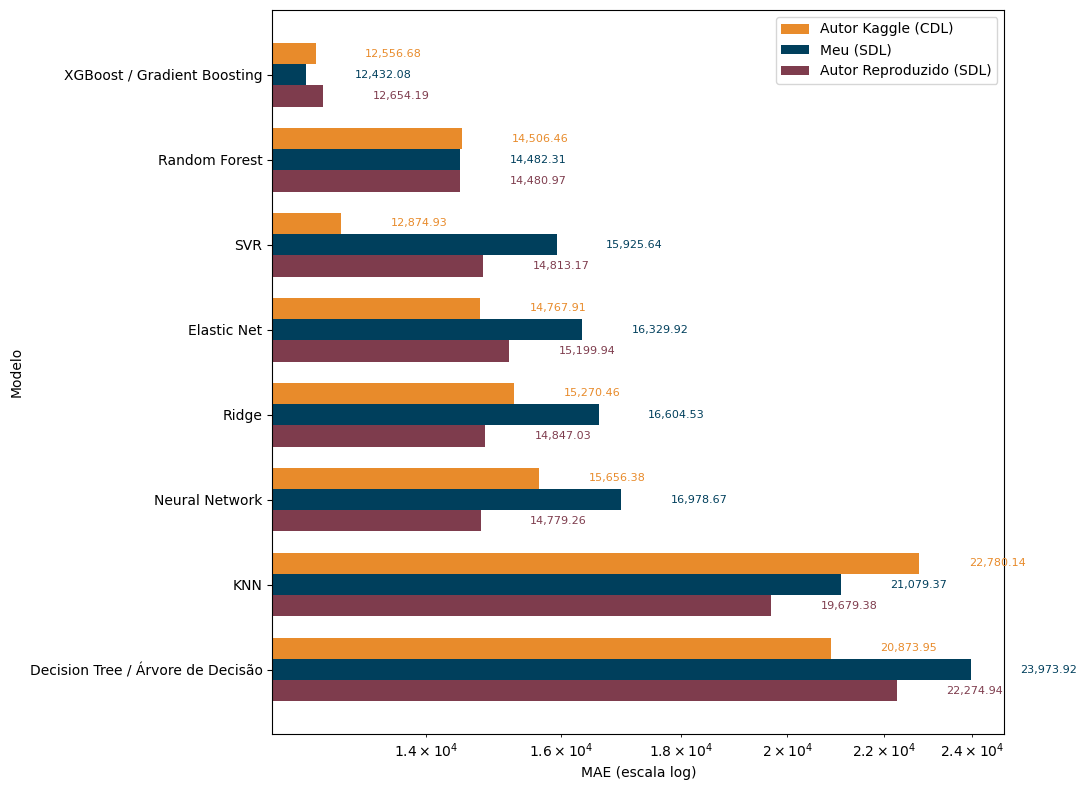

In [191]:
from matplotlib import pyplot as plt
import numpy as np

tabela_ordenada = tabela_comparativa.sort_values(by="MAE Meu (SDL)").reset_index(drop=True)

x = tabela_ordenada["Modelo"].tolist()
autor_cdl = tabela_ordenada["MAE Autor Kaggle (CDL)"].tolist()
meu_sdl = tabela_ordenada["MAE Meu (SDL)"].tolist()
autor_sdl = tabela_ordenada["MAE Autor Reproduzido (SDL)"].tolist()

ind = np.arange(len(x))
height = 0.25

fig, ax = plt.subplots(figsize=(11, 8))

b1 = ax.barh(ind - height, autor_cdl, height, color="#e88b2b", label="Autor Kaggle (CDL)")
b2 = ax.barh(ind, meu_sdl, height, color="#003f5c", label="Meu (SDL)")
b3 = ax.barh(ind + height, autor_sdl, height, color="#7e3c4d", label="Autor Reproduzido (SDL)")

ax.set_xscale("log")
ax.set_yticks(ind)
ax.set_yticklabels(x)
ax.invert_yaxis()  # menor MAE no topo
ax.set_xlabel("MAE (escala log)")
ax.set_ylabel("Modelo")
ax.legend()

for bar, valor in zip(b1, autor_cdl):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f"{valor:,.2f}", va="center", fontsize=8, color="#e88b2b")

for bar, valor in zip(b2, meu_sdl):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f"{valor:,.2f}", va="center", fontsize=8, color="#003f5c")

for bar, valor in zip(b3, autor_sdl):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f"{valor:,.2f}", va="center", fontsize=8, color="#7e3c4d")

plt.tight_layout()
plt.show()

Essa comparação entre os três cenários (autor no Kaggle, minha abordagem e a abordagem do autor reproduzida) tem o objetivo de tornar visíveis as diferenças entre as decisões metodológicas tomadas ao longo do projeto. Existem outras formas mais rigorosas de conduzir essa comparação  — mas esse não é o objetivo aqui: este notebook não pretende ser um estudo científico, e sim um projeto de portfólio voltado à demonstração de habilidades práticas em ciência de dados.

Por fim, acredito que existam muitos fatores capazes de influenciar o resultado final de um modelo — seja ele um regressor, um classificador, um algoritmo de clusterização, entre outros. Hoje ainda não consigo apontar com segurança qual é a combinação ideal de decisões para um determinado problema; entendo que essa sensibilidade se desenvolve com a prática, resolvendo problemas cada vez mais variados e observando o que funciona (e o que não funciona) em cada contexto. É justamente por isso que considero tão importante ingressar no mercado de trabalho: é na prática constante, com problemas reais e diversos, que essa capacidade de julgamento se forma.

LFRP